# Data Exploration

## 1. Import Statements

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import random
from collections import Counter


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Load Images

In [2]:
real_dir = "../data/Input/real"
comic_dir = "../data/Input/comic"

real_images = sorted(glob(os.path.join(real_dir, "*")))
comic_images = sorted(glob(os.path.join(comic_dir, "*")))

print("Real images:", len(real_images))
print("Comic images:", len(comic_images))

Real images: 10000
Comic images: 10000


In [3]:
# check if all pairs match

mismatch_count = 0
match_count = 0

for i in range(len(real_images)):
    image_name = os.path.basename(real_images[i])
    comic_name = os.path.basename(comic_images[i])
    if image_name != comic_name:
        print(f"Mismatch: {image_name} != {comic_name}")
        mismatch_count += 1
    else:
        match_count += 1

print(f"Total matches: {match_count}")
print(f"Total mismatches: {mismatch_count}")

Total matches: 10000
Total mismatches: 0


## 3. Check Random Samples

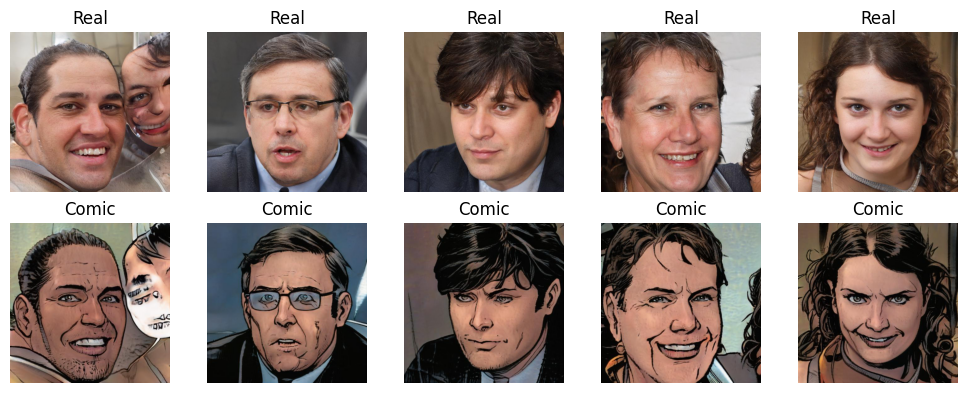

In [4]:
def show_random_samples(n=5):
    idxs = random.sample(range(len(real_images)), n)

    plt.figure(figsize=(10, 4))

    for i, idx in enumerate(idxs):
        real = cv2.cvtColor(cv2.imread(real_images[idx]), cv2.COLOR_BGR2RGB)
        comic = cv2.cvtColor(cv2.imread(comic_images[idx]), cv2.COLOR_BGR2RGB)

        plt.subplot(2, n, i + 1)
        plt.imshow(real)
        plt.title("Real")
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(comic)
        plt.title("Comic")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples()

## 4. Inspect Image

In [5]:
# check the shape of the images

shapes_real = set()
shapes_comic = set()

for i in range(10000):
    r = cv2.imread(real_images[i]).shape
    c = cv2.imread(comic_images[i]).shape
    shapes_real.add(r)
    shapes_comic.add(c)

print("Real shapes:", shapes_real)
print("Comic shapes:", shapes_comic)

Real shapes: {(512, 512, 3)}
Comic shapes: {(512, 512, 3)}


In [6]:
# get the shape counts of the images

def get_shape_counts(images):
    counts = Counter()
    for i in range(10000):
        img = cv2.imread(images[i])
        counts[img.shape[:2]] += 1
    return counts

print("Real:", get_shape_counts(real_images))
print("Comic:", get_shape_counts(comic_images))

Real: Counter({(512, 512): 10000})
Comic: Counter({(512, 512): 10000})


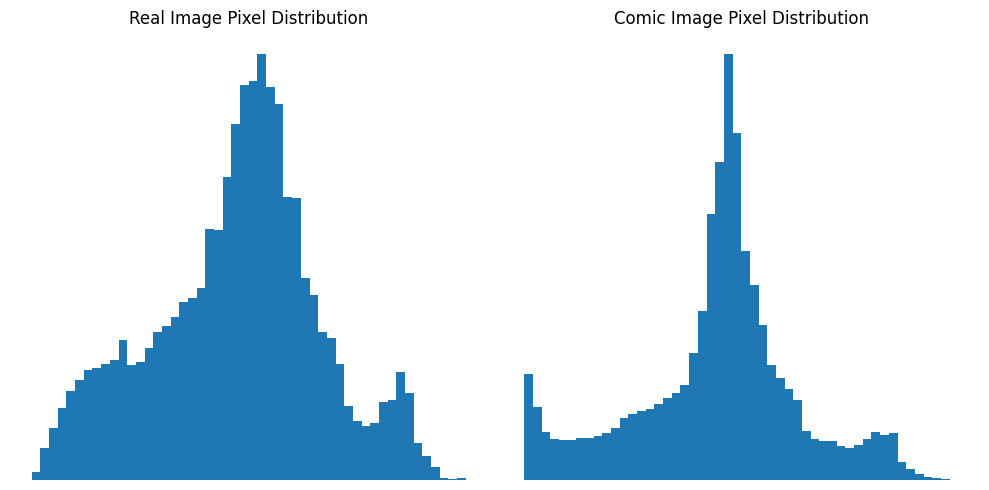

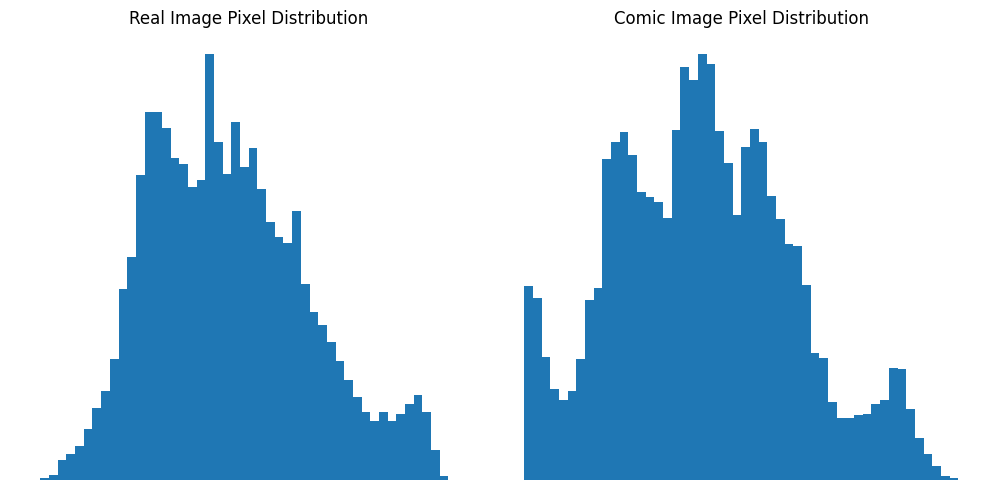

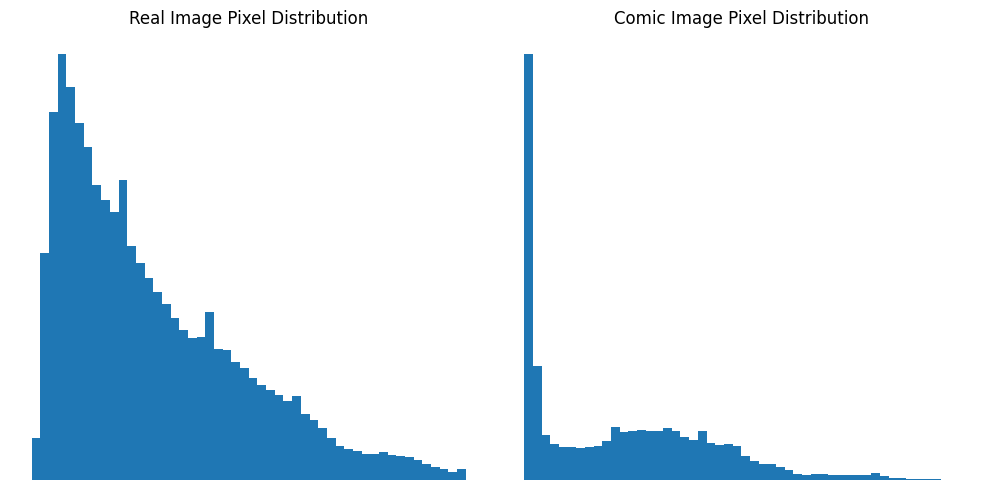

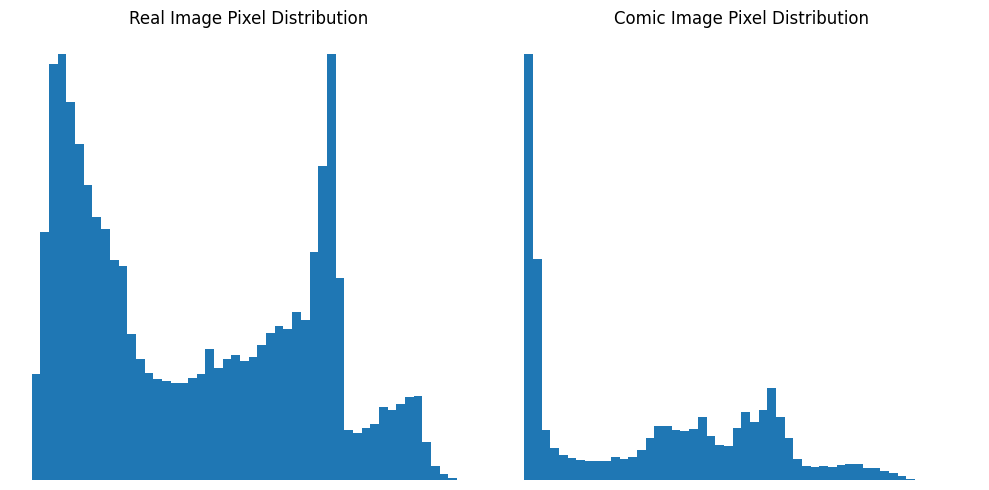

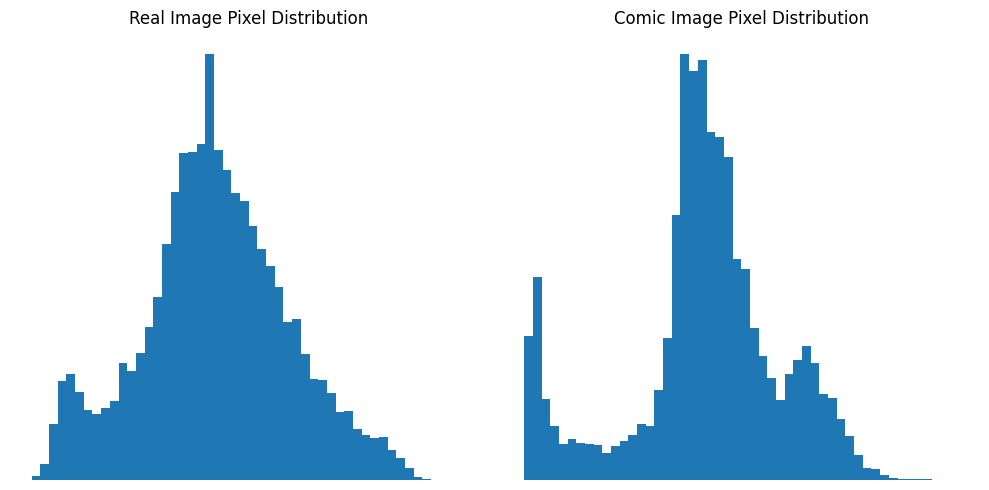

In [7]:
# plot the pixel distribution of the images

for i in range(5):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5)) 

    real = cv2.imread(real_images[i])
    real = cv2.cvtColor(real, cv2.COLOR_BGR2RGB)
    axes[0].hist(real.ravel(), bins=50)
    axes[0].set_title("Real Image Pixel Distribution")
    axes[0].axis("off")


    comic = cv2.imread(comic_images[i])
    comic = cv2.cvtColor(comic, cv2.COLOR_BGR2RGB)
    axes[1].hist(comic.ravel(), bins=50)
    axes[1].set_title("Comic Image Pixel Distribution")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


## 5. Sample Images

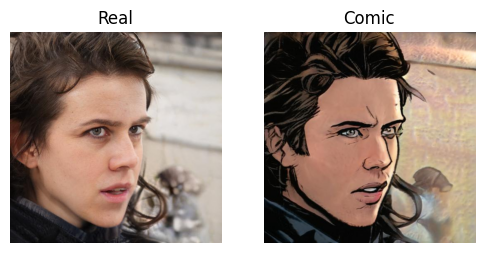

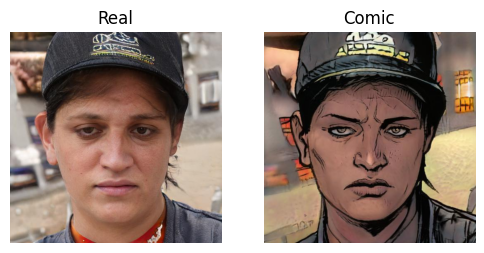

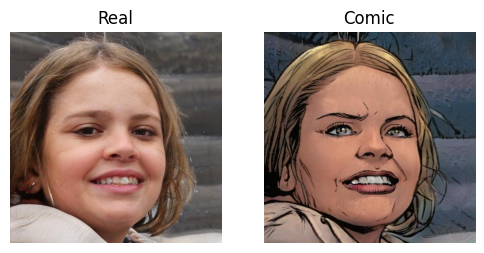

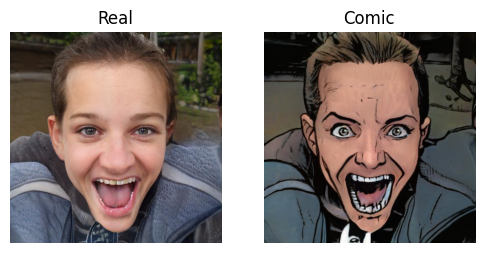

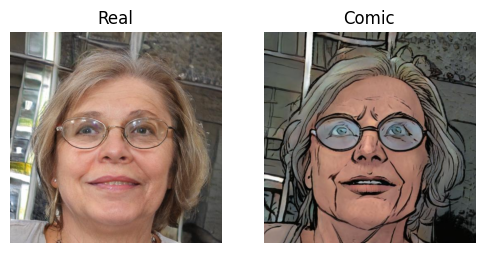

In [8]:
def compare(idx):
    real = cv2.cvtColor(cv2.imread(real_images[idx]), cv2.COLOR_BGR2RGB)
    comic = cv2.cvtColor(cv2.imread(comic_images[idx]), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(real)
    plt.title("Real")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(comic)
    plt.title("Comic")
    plt.axis("off")

    plt.show()

for i in range(5):
    n = random.randint(0, len(real_images) - 1)
    compare(n)

## 6. Key Findings:

- **Dataset Balance**: Real and comic image pairs are well-matched with consistent naming conventions
- **Paired Data**: All real-comic image pairs are properly aligned and of similar sizes, which will make preprocessing easier.